In [2]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv')

In [4]:
df.shape

(529918, 79)

In [5]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
df.columns.tolist()

[' Destination Port',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Bwd PSH Flags',
 ' Fwd URG Flags',
 ' Bwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std',
 ' Packet Length Variance',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' P

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [9]:
df['Label'].value_counts()

Label
BENIGN    529918
Name: count, dtype: int64

In [10]:
df.describe()

/home/kvasir/ids-ml/venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/kvasir/ids-ml/venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,529918.000000,5.299180e+05,529918.000000,529918.000000,5.299180e+05,5.299180e+05,529918.000000,529918.000000,529918.000000,529918.000000,...,529918.000000,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05
mean,10644.367112,1.038927e+07,10.390315,11.517105,5.324195e+02,1.789841e+04,190.897188,20.277279,50.744078,57.452269,...,7.412509,-3.614576e+03,6.843482e+04,4.321930e+04,1.453907e+05,4.380369e+04,3.463918e+06,2.024408e+05,3.620657e+06,3.274066e+06
std,21390.213475,2.875195e+07,892.412791,1173.318788,6.228642e+03,2.675470e+06,448.833754,36.275793,91.964713,146.518081,...,851.762351,5.526328e+05,5.872322e+05,3.971455e+05,1.028606e+06,4.993677e+05,1.297057e+07,2.170149e+06,1.340649e+07,1.273216e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.760000e+02,2.000000,1.000000,1.800000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.130300e+04,2.000000,2.000000,6.800000e+01,1.440000e+02,40.000000,6.000000,38.000000,0.000000,...,1.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,3.557448e+05,4.000000,3.000000,1.870000e+02,3.920000e+02,83.000000,40.000000,53.000000,26.162951,...,3.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65535.000000,1.200000e+08,219759.000000,291922.000000,1.323378e+06,6.554530e+08,23360.000000,2293.000000,4638.923469,7125.596846,...,213557.000000,1.260000e+02,1.016597e+08,6.434950e+07,1.016597e+08,1.016597e+08,1.199997e+08,7.514502e+07,1.199997e+08,1.199997e+08


In [11]:
df.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64

In [12]:
df[df['Flow Duration']<0].shape

(15, 79)

In [13]:
df = df[df['Flow Duration']>=0]
df.shape

(529903, 79)

In [14]:
import os
ruta = '../data/raw/MachineLearningCVE/'
archivos = os.listdir(ruta)
print(archivos)

['Tuesday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv']


In [15]:
dfs = []

for archivo in archivos:
    ruta_completa = ruta + archivo
    df_temp = pd.read_csv(ruta_completa)
    df_temp.columns = df_temp.columns.str.strip()
    dfs.append(df_temp)

df_total = pd.concat(dfs, ignore_index=True)
df_total.shape

(2830743, 79)

In [16]:
df_total['Label'].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

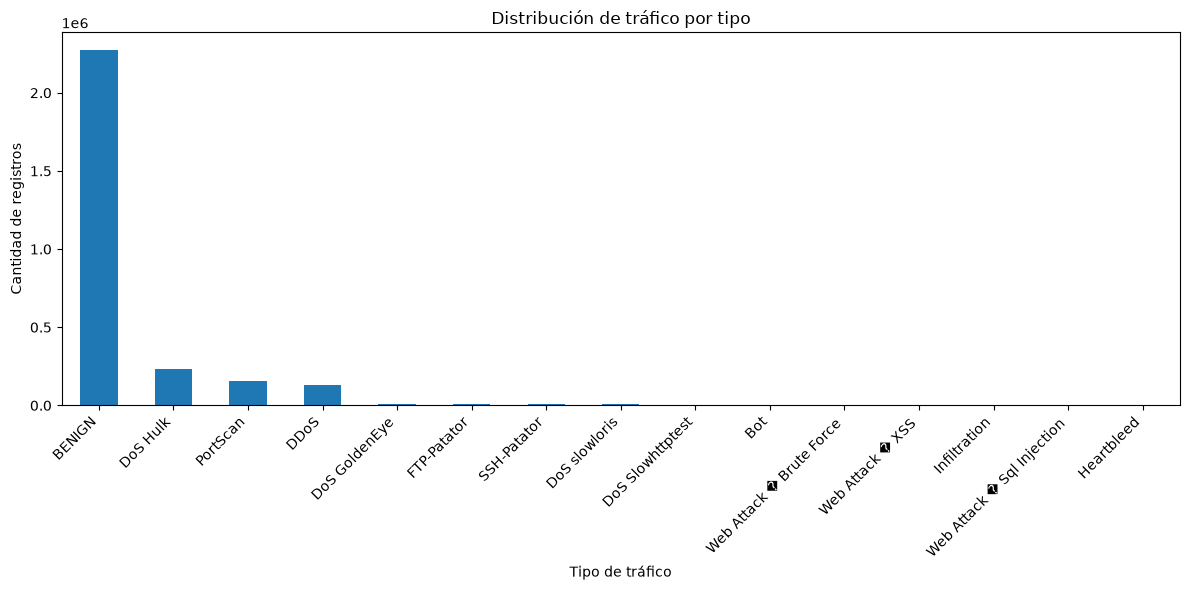

In [17]:
plt.figure(figsize=(12, 6))
df_total['Label'].value_counts().plot(kind='bar')
plt.title('Distribución de tráfico por tipo')
plt.xlabel('Tipo de tráfico')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

inf_count = np.isinf(df_total.select_dtypes(include=np.number)).sum()
inf_count[inf_count > 0]


Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64

In [19]:
df_total.replace([np.inf, -np.inf], np.nan, inplace=True)
df_total.dropna(inplace=True)
df_total.shape

(2827876, 79)

In [20]:
## Limpieza de datos

- Eliminadas 15 filas con `Flow Duration` negativa
- No se encontraron valores nulos en el dataset
- Reemplazados valores infinitos en `Flow Bytes/s` y `Flow Packets/s` por NaN y eliminadas esas filas
- Dataset final: 2,827,876 registros × 79 columnas

SyntaxError: invalid character '×' (U+00D7) (1582198795.py, line 6)

## Limpieza de datos

- Eliminadas 15 filas con `Flow Duration` negativa
- No se encontraron valores nulos en el dataset
- Reemplazados valores infinitos en `Flow Bytes/s` y `Flow Packets/s` por NaN y eliminadas esas filas
- Dataset final: 2,827,876 registros × 79 columnas

In [21]:
df_benign = df_total[df_total['Label'] == 'BENIGN']
df_attack = df_total[df_total['Label'] != 'BENIGN']

print(f'Tráfico benigno: {df_benign.shape[0]} registros')
print(f'Tráfico malicioso: {df_attack.shape[0]} registros')

Tráfico benigno: 2271320 registros
Tráfico malicioso: 556556 registros


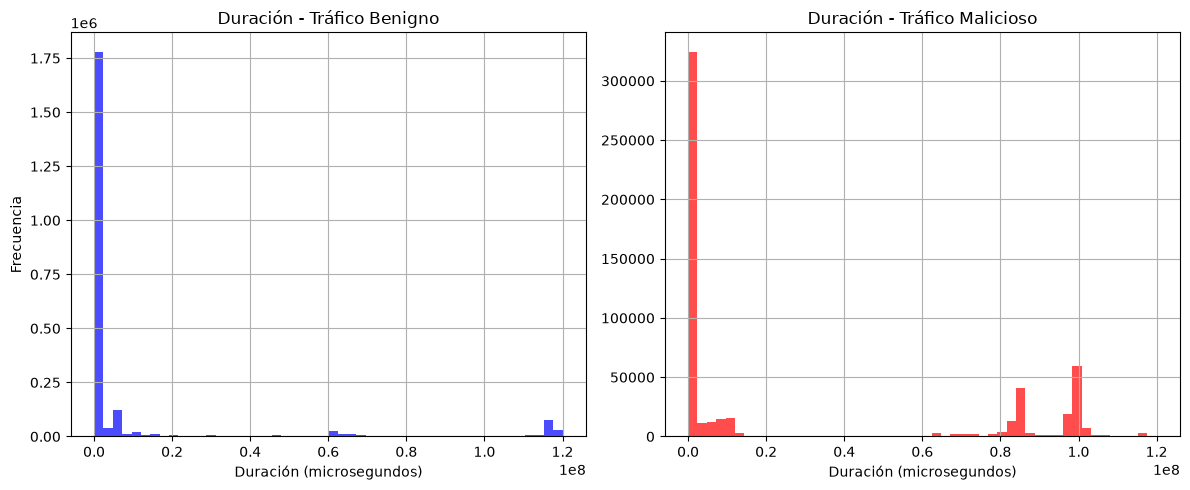

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_benign['Flow Duration'].hist(bins=50, color='blue', alpha=0.7)
plt.title('Duración - Tráfico Benigno')
plt.xlabel('Duración (microsegundos)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
df_attack['Flow Duration'].hist(bins=50, color='red', alpha=0.7)
plt.title('Duración - Tráfico Malicioso')
plt.xlabel('Duración (microsegundos)')

plt.tight_layout()
plt.show()

## Análisis comparativo: Benigno vs Malicioso

- El tráfico benigno se concentra en flujos muy cortos
- El tráfico malicioso muestra distribución más dispersa en duraciones intermedias
- La duración del flujo es una característica potencialmente útil para clasificación